<h2 style="text-align : center"> Reproducing the paper titled "Predicting the direction of stock market prices using random forest" <a href="https://arxiv.org/abs/1605.00003">Paper</a> </h2> 

<h4>Authors :  
Luckyson Khaidem,
Snehanshu Saha,
Sudeepa Roy Dey</h4>

In [85]:
# Importing the libraries

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_technical_indicators as ta

In [86]:
# Function to load data from the csv file

def load_data() :
    appl_path = Path("datasets/AAPL.csv")
    return pd.read_csv(appl_path)

In [87]:
# Function to save the plots in the images directory

IMAGE_PATH = Path() /"images"
IMAGE_PATH.mkdir(parents=True,exist_ok=True)

def save_fig(fig_name,fig_extension='png',resolution=300,tight_layout= True) :

    image_path = IMAGE_PATH/f"{fig_name}.{fig_extension}"
    if tight_layout :
        plt.tight_layout()
    plt.savefig(image_path,format=fig_extension,dpi=resolution)


In [ ]:
# Loading the data and dropping unimportant features

stock = load_data()
stock = stock.drop(["Date","Adj Close"],axis=1)

In [90]:
# Function for exponential smoothing of data

def exp_smoothing(df,alpha=0.9) :
    return df.ewm(alpha=alpha).mean()

In [91]:
# Smoothing the stock data

smooth_stock = exp_smoothing(stock)

The indicators used are taken from Peter Bakker at: https://www.quantopian.com/posts/technical-analysis-indicators-without-talib-code

In [92]:
# Feature Extraction - Technical Indicators

def feature_extraction(data) :
    for x in [5, 14, 28, 49, 63,82,90]:
        data = ta.relative_strength_index(data, n=x)
        data = ta.stochastic_oscillator_d(data, n=x)
        data = ta.accumulation_distribution(data, n=x)
        data = ta.average_true_range(data, n=x)
        data = ta.momentum(data, n=x)
        data = ta.money_flow_index(data, n=x)
        data = ta.rate_of_change(data, n=x)
        data = ta.on_balance_volume(data, n=x)
        data = ta.commodity_channel_index(data, n=x)
        data = ta.ease_of_movement(data, n=x)
        data = ta.trix(data, n=x)
        data = ta.vortex_indicator(data, n=x)
    
    data['ema50'] = data['Close'] / data['Close'].ewm(50).mean()
    data['ema21'] = data['Close'] / data['Close'].ewm(21).mean()
    data['ema14'] = data['Close'] / data['Close'].ewm(14).mean()
    data['ema5'] = data['Close'] / data['Close'].ewm(5).mean()
        
    #Williams %R is missing
    data = ta.macd(data, n_fast=12, n_slow=26)

    data = data.drop(["Open","Volume","High","Low"],axis=1)

    return data

In [93]:
# Computing the predictions

def compute_prediction(df, n):
    pred = (df.shift(-n)['Close'] >= df['Close'])
    pred = pred.iloc[:-n]
    return pred.astype(int)

# Preparing the data by adding important features

def prepare_data(df, horizon):
    data = feature_extraction(df).dropna().iloc[:-horizon]
    data['pred'] = compute_prediction(data, n=horizon)
    del(data['Close'])
    return data.dropna()

Preparing the data for span of 10 days to compare it with the results obtained in Paper (Page-18, Fig-15) with Apple Dataset

In [94]:
data = prepare_data(smooth_stock,10)
y= data["pred"]

X = data.drop("pred",axis=1)

Splitting the data using Scikit learn and forming a pipeline of Random Forest Classifier

In [95]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

X_train,X_test,y_train,y_test = train_test_split(X.to_numpy(),y.to_numpy(),test_size=0.3,random_state=42)

forest_pip = make_pipeline(RandomForestClassifier(random_state=42,n_jobs=-1))


Searching for the best parameters of Random forest using RandomizedSearchCV

In [96]:
from scipy.stats import randint

params = [{
    "randomforestclassifier__n_estimators" : randint(10,500),
    
}]

rnd_search_cv = RandomizedSearchCV(forest_pip,params,cv=3,random_state=42,n_iter=10)
rnd_search_cv.fit(X_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('randomforestclassifier',
                                              RandomForestClassifier(n_jobs=-1,
                                                                     random_state=42))]),
                   param_distributions=[{'randomforestclassifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000015B618E3710>}],
                   random_state=42)

The estimator performs best when the parameter n_estimators(ie Decision trees) = <strong>280</strong>

In [97]:
rnd_search_cv.best_params_


{'randomforestclassifier__n_estimators': 280}

Wow ! Got an accuracy of <b>91.07 %</b> very close to that published in paper (<b>92.08 %</b>)

In [98]:
rnd_search_cv.best_estimator_.score(X_test,y_test)

0.9107806691449815

In [99]:
y_pred = rnd_search_cv.best_estimator_.predict(X_test)
y_proba = rnd_search_cv.best_estimator_.predict_proba(X_test)

Plotting the graphs of prediction versus the real label

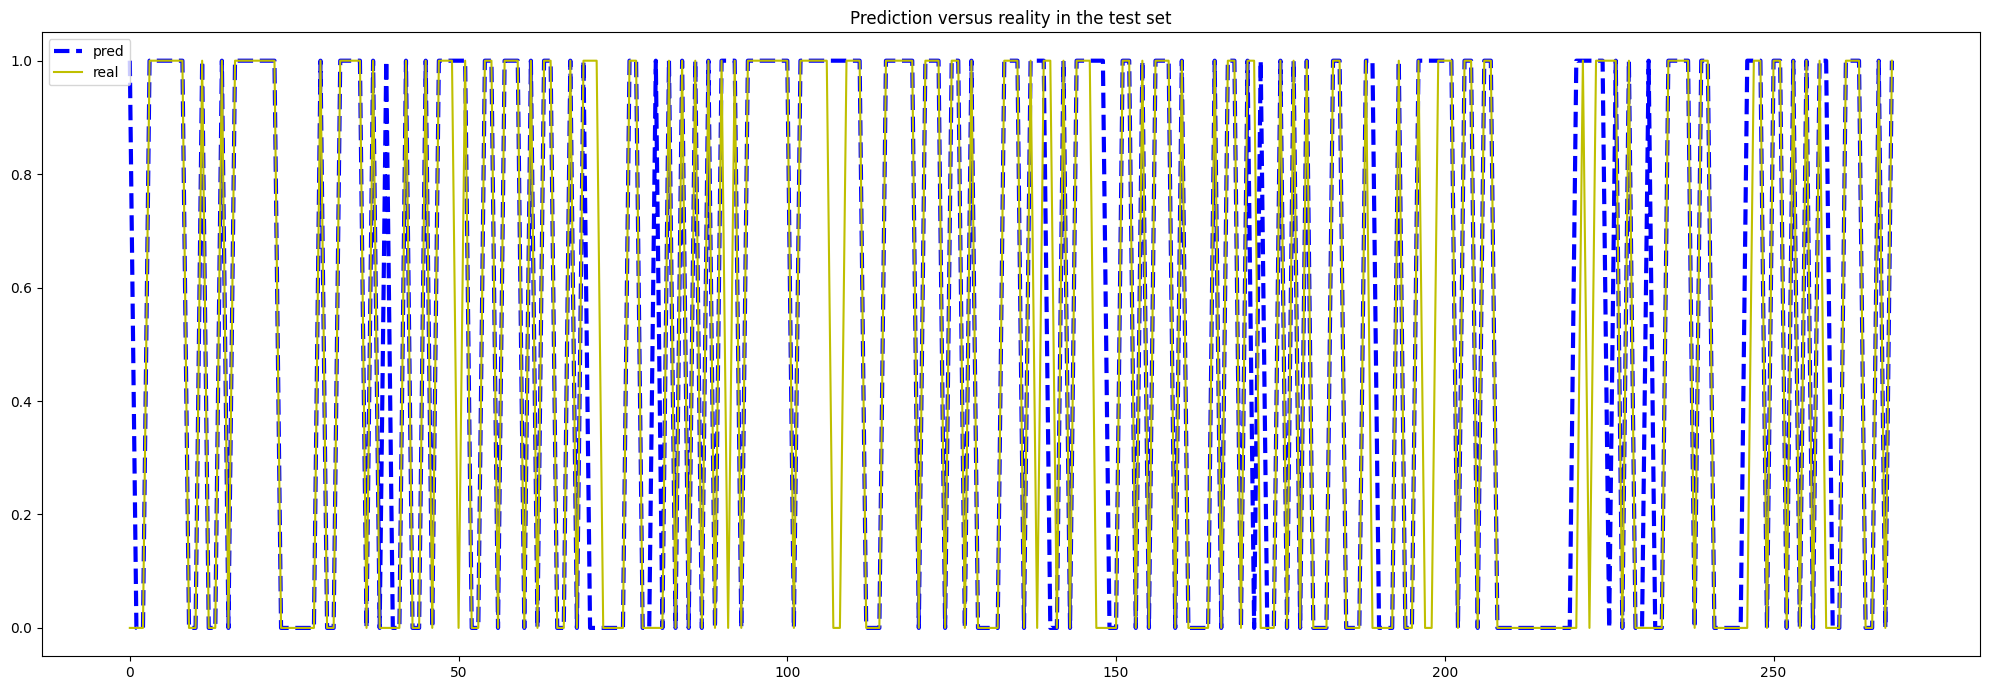

In [100]:
plt.figure(figsize=(20,7))
plt.plot(np.arange(len(y_pred)), y_pred,"b--",linewidth=3, label='pred')
plt.plot(np.arange(len(y_test)), y_test,"y-", label='real' )
plt.title('Prediction versus reality in the test set')
plt.legend(loc="upper left")
save_fig("Prediction vs Reality graph")
plt.show()

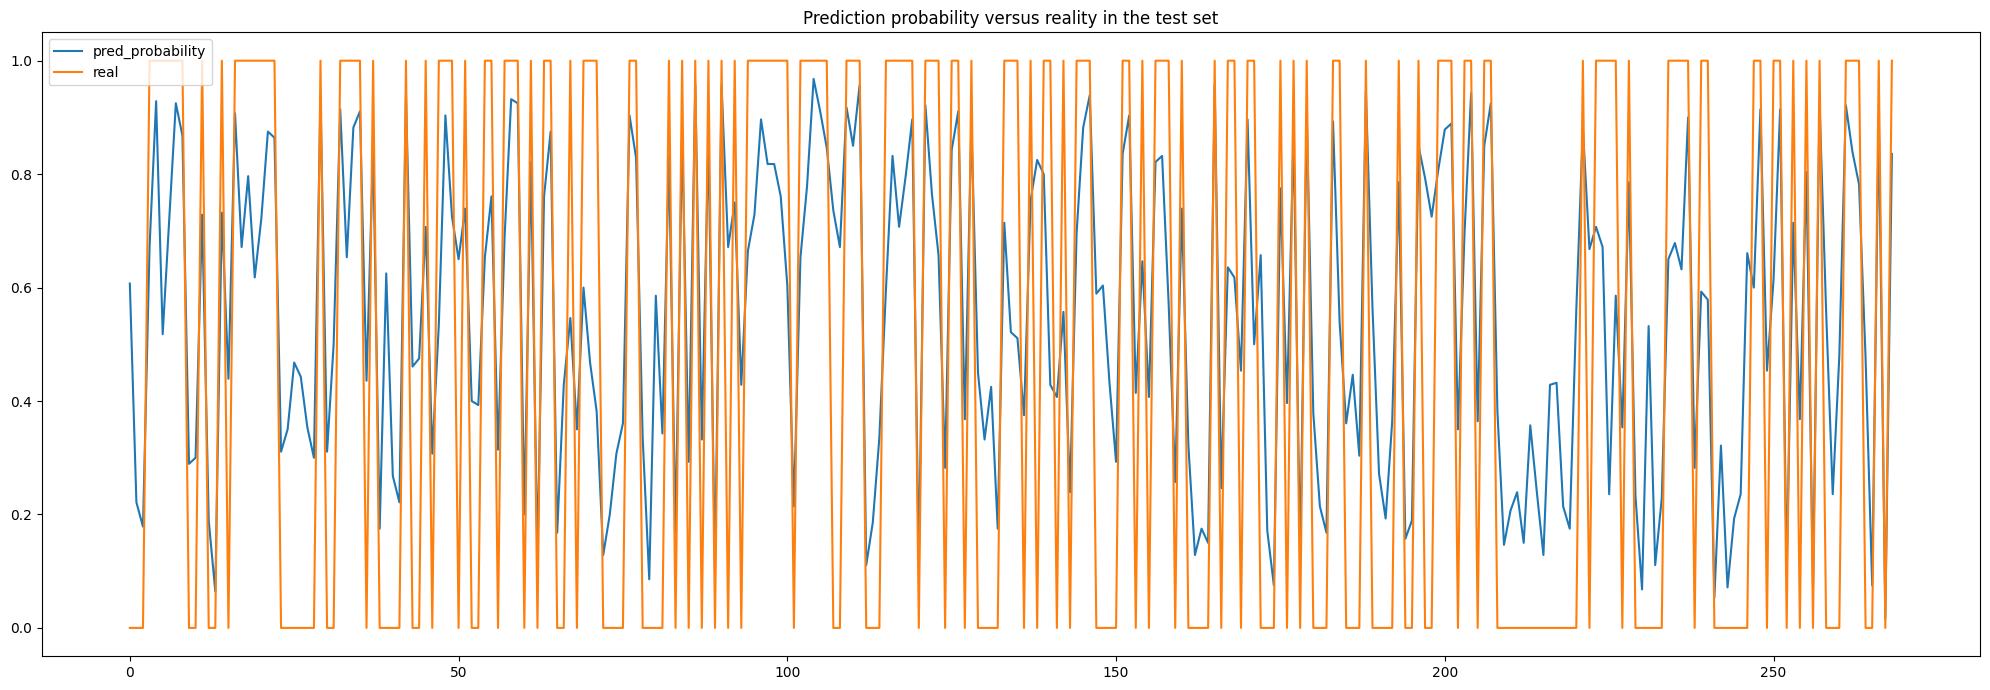

In [101]:
plt.figure(figsize=(20,7))
plt.plot(np.arange(len(y_proba)), y_proba[:,1], label='pred_probability')
plt.plot(np.arange(len(y_test)), y_test, label='real' )
plt.title('Prediction probability versus reality in the test set')
plt.legend(loc="upper left")
save_fig("Prediction probability vs Reality graph")
plt.show()